# Phase 3.2 — Fusion Architectures

**Goal:** Train and compare four fusion architectures that combine behavioral + NLP features.

## Architectures
1. **Early Fusion (XGBoost)** — concatenate → gradient boosted trees
2. **Late Fusion (Ensemble)** — separate behavioral + NLP models → weighted average
3. **Intermediate Fusion (MLP)** — PCA-compressed → neural network
4. **Stacking** — behavioral + NLP predictions as meta-features → LR meta-learner

All architectures trained with 5-fold CV and class balancing.

In [1]:
import sys, warnings, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc,
    precision_score, recall_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
MODEL_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
FUSION_DIR  = PROJECT_ROOT / 'fusion_models' / 'results'
for d in [MODEL_DIR, RESULTS_DIR, FUSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Setup complete')

✓ Setup complete


## 2. Load Aligned Feature Matrices

From Phase 3.1 (`01_feature_alignment.ipynb`). Falls back to regenerating if not found.

In [2]:
def load_or_generate_features():
    """Load saved feature matrices or regenerate from scratch."""
    required = ['X_beh_train.npy','X_beh_val.npy','X_nlp_train.npy','X_nlp_val.npy','y_train.npy','y_val.npy']
    if all((MODEL_DIR / f).exists() for f in required):
        print('✓ Loading saved feature matrices from models/')
        X_beh_train = np.load(MODEL_DIR / 'X_beh_train.npy')
        X_beh_val   = np.load(MODEL_DIR / 'X_beh_val.npy')
        X_nlp_train = np.load(MODEL_DIR / 'X_nlp_train.npy')
        X_nlp_val   = np.load(MODEL_DIR / 'X_nlp_val.npy')
        y_train     = np.load(MODEL_DIR / 'y_train.npy')
        y_val       = np.load(MODEL_DIR / 'y_val.npy')
        return X_beh_train, X_beh_val, X_nlp_train, X_nlp_val, y_train, y_val

    # Regenerate (re-runs 01_feature_alignment logic inline)
    print('Feature matrices not found — regenerating...')
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD

    rng = np.random.default_rng(42)
    n = 3000
    real_t = ['Scientists confirm {} in peer-reviewed study',
               'Government announces {} budget increase for {}']
    fake_t = ['BREAKING: {} secretly {} — insiders reveal truth',
               'EXPOSED: Scientists HIDE {} from public']
    topics = ['climate','vaccines','the economy','5G','pharmaceuticals','elections']
    titles, labels = [], []
    for tmpl_list, label in [(real_t,'real'),(fake_t,'fake')]:
        for _ in range(n//2):
            tmpl = tmpl_list[rng.integers(len(tmpl_list))]
            t1,t2 = topics[rng.integers(len(topics))],topics[rng.integers(len(topics))]
            try: titles.append(tmpl.format(t1,t2))
            except: titles.append(tmpl.format(t1))
            labels.append(label)

    df = pd.DataFrame({'title':titles,'label':labels})
    df['label_num'] = (df['label']=='fake').astype(int)
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label_num'], random_state=42)

    # Behavioral (simulated)
    def gen_beh(n_):
        r = np.random.default_rng(42)
        return np.column_stack([
            np.clip(r.normal(3.2,1.8,n_).round(),0,7),
            np.clip(r.normal(3.4,0.7,n_),1,5),
            r.choice([1,2,3,4,5],n_),
            np.clip(r.normal(4.0,1.5,n_).round(),1,7),
            np.clip(r.exponential(2.5,n_),0,12),
            np.clip(r.normal(3.1,0.9,n_),1,5),
            r.beta(2,5,n_),
        ])

    sc = StandardScaler()
    X_beh_train = sc.fit_transform(gen_beh(len(train_df)))
    X_beh_val   = sc.transform(gen_beh(len(val_df)))

    # NLP (TF-IDF + SVD)
    tfidf = TfidfVectorizer(stop_words='english', max_features=2000, ngram_range=(1,2), sublinear_tf=True)
    svd   = TruncatedSVD(n_components=64, random_state=42)
    X_nlp_train = svd.fit_transform(tfidf.fit_transform(train_df['title']))
    X_nlp_val   = svd.transform(tfidf.transform(val_df['title']))

    y_train = train_df['label_num'].values
    y_val   = val_df['label_num'].values
    print(f'Generated: beh={X_beh_train.shape}, nlp={X_nlp_train.shape}')
    return X_beh_train, X_beh_val, X_nlp_train, X_nlp_val, y_train, y_val

X_beh_train, X_beh_val, X_nlp_train, X_nlp_val, y_train, y_val = load_or_generate_features()

# Combined early fusion matrix
X_early_train = np.hstack([X_beh_train, X_nlp_train])
X_early_val   = np.hstack([X_beh_val,   X_nlp_val])

print(f'Behavioral: {X_beh_train.shape} | NLP: {X_nlp_train.shape} | Combined: {X_early_train.shape}')
print(f'Labels — train: {y_train.mean():.2%} fake | val: {y_val.mean():.2%} fake')

✓ Loading saved feature matrices from models/
Behavioral: (2400, 7) | NLP: (2400, 384) | Combined: (2400, 391)
Labels — train: 50.00% fake | val: 50.00% fake


## 3. Architecture 1 — Early Fusion (Gradient Boosting)

Concatenate all features → train a single GBT model. Simple but powerful.

In [3]:
import time

fusion_results = {}

# --- Architecture 1: Early Fusion with Gradient Boosting
print('1. Early Fusion (Gradient Boosting)...')
t0 = time.time()
gbm = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42
)
gbm.fit(X_early_train, y_train)
preds_gbm = gbm.predict(X_early_val)
proba_gbm = gbm.predict_proba(X_early_val)[:, 1]

fusion_results['Early Fusion (GBM)'] = {
    'accuracy':  accuracy_score(y_val, preds_gbm),
    'f1':        f1_score(y_val, preds_gbm, average='binary'),
    'precision': precision_score(y_val, preds_gbm, zero_division=0),
    'recall':    recall_score(y_val, preds_gbm, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_gbm),
    'brier':     brier_score_loss(y_val, proba_gbm),
    'train_time': round(time.time()-t0, 2),
    'proba': proba_gbm,
    'preds': preds_gbm,
}
joblib.dump(gbm, MODEL_DIR / 'fusion_early_gbm.joblib')
r = fusion_results['Early Fusion (GBM)']
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

1. Early Fusion (Gradient Boosting)...


  AUC=1.0000  F1=1.0000  (13.81s)


## 4. Architecture 2 — Late Fusion (Weighted Ensemble)

Train separate models on behavioral and NLP features, then average their probability outputs.

In [4]:
print('2. Late Fusion (Weighted Ensemble)...')
t0 = time.time()

# Behavioral-only model
clf_beh = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
clf_beh.fit(X_beh_train, y_train)
proba_beh = clf_beh.predict_proba(X_beh_val)[:, 1]

# NLP-only model
clf_nlp = LogisticRegression(C=1.0, max_iter=1000, random_state=42, class_weight='balanced')
clf_nlp.fit(X_nlp_train, y_train)
proba_nlp = clf_nlp.predict_proba(X_nlp_val)[:, 1]

# Optimize ensemble weight via grid search
best_auc, best_w = 0, 0.5
for w in np.arange(0.0, 1.01, 0.05):
    proba_ens = w * proba_beh + (1 - w) * proba_nlp
    auc_w = roc_auc_score(y_val, proba_ens)
    if auc_w > best_auc:
        best_auc, best_w = auc_w, w

proba_late = best_w * proba_beh + (1 - best_w) * proba_nlp
preds_late = (proba_late >= 0.5).astype(int)

fusion_results['Late Fusion (Ensemble)'] = {
    'accuracy':  accuracy_score(y_val, preds_late),
    'f1':        f1_score(y_val, preds_late, average='binary'),
    'precision': precision_score(y_val, preds_late, zero_division=0),
    'recall':    recall_score(y_val, preds_late, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_late),
    'brier':     brier_score_loss(y_val, proba_late),
    'train_time': round(time.time()-t0, 2),
    'best_weight': round(best_w, 2),
    'proba': proba_late,
    'preds': preds_late,
}

r = fusion_results['Late Fusion (Ensemble)']
print(f'  Optimal weight (behavioral): {best_w:.2f}')
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

2. Late Fusion (Weighted Ensemble)...


  Optimal weight (behavioral): 0.00
  AUC=1.0000  F1=1.0000  (0.19s)


## 5. Architecture 3 — Intermediate Fusion (MLP)

PCA-compressed features → 3-layer neural network capturing non-linear interactions.

In [5]:
from sklearn.decomposition import PCA

print('3. Intermediate Fusion (MLP)...')
t0 = time.time()

pca_beh = PCA(n_components=min(4, X_beh_train.shape[1]), random_state=42)
pca_nlp = PCA(n_components=min(32, X_nlp_train.shape[1]), random_state=42)

X_beh_pca_tr = pca_beh.fit_transform(X_beh_train)
X_nlp_pca_tr = pca_nlp.fit_transform(X_nlp_train)
X_int_train  = np.hstack([X_beh_pca_tr, X_nlp_pca_tr])

X_beh_pca_vl = pca_beh.transform(X_beh_val)
X_nlp_pca_vl = pca_nlp.transform(X_nlp_val)
X_int_val    = np.hstack([X_beh_pca_vl, X_nlp_pca_vl])

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1, alpha=1e-4
)
mlp.fit(X_int_train, y_train)
preds_mlp = mlp.predict(X_int_val)
proba_mlp = mlp.predict_proba(X_int_val)[:, 1]

fusion_results['Intermediate Fusion (MLP)'] = {
    'accuracy':  accuracy_score(y_val, preds_mlp),
    'f1':        f1_score(y_val, preds_mlp, average='binary'),
    'precision': precision_score(y_val, preds_mlp, zero_division=0),
    'recall':    recall_score(y_val, preds_mlp, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_mlp),
    'brier':     brier_score_loss(y_val, proba_mlp),
    'train_time': round(time.time()-t0, 2),
    'input_dim': X_int_train.shape[1],
    'proba': proba_mlp,
    'preds': preds_mlp,
}

joblib.dump(mlp, MODEL_DIR / 'fusion_intermediate_mlp.joblib')
r = fusion_results['Intermediate Fusion (MLP)']
print(f'  Input dim: {X_int_train.shape[1]} (PCA-compressed)')
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

3. Intermediate Fusion (MLP)...


  Input dim: 36 (PCA-compressed)
  AUC=1.0000  F1=1.0000  (0.71s)


## 6. Architecture 4 — Stacking (Meta-Learner)

Base models produce probability predictions → meta-learner (LR) learns optimal combination.

In [6]:
print('4. Stacking (Meta-Learner)...')
t0 = time.time()

# Generate OOF (out-of-fold) predictions for meta-training
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Base models
base_models = {
    'beh_lr': LogisticRegression(C=1.0, max_iter=500, random_state=42, class_weight='balanced'),
    'nlp_lr': LogisticRegression(C=1.0, max_iter=500, random_state=42, class_weight='balanced'),
    'early_rf': RandomForestClassifier(n_estimators=50, max_depth=6, random_state=42, class_weight='balanced'),
}
base_inputs = {
    'beh_lr': (X_beh_train, X_beh_val),
    'nlp_lr': (X_nlp_train, X_nlp_val),
    'early_rf': (X_early_train, X_early_val),
}

# OOF training set for meta-learner
meta_train = np.zeros((len(y_train), len(base_models)))
meta_val   = np.zeros((len(y_val),   len(base_models)))

for col, (name, clf) in enumerate(base_models.items()):
    Xtr, Xvl = base_inputs[name]
    oof_proba = cross_val_predict(clf, Xtr, y_train, cv=skf, method='predict_proba')[:, 1]
    meta_train[:, col] = oof_proba
    clf.fit(Xtr, y_train)
    meta_val[:, col] = clf.predict_proba(Xvl)[:, 1]
    print(f'  Base [{name}]: OOF AUC={roc_auc_score(y_train, oof_proba):.4f}')

# Train meta-learner
meta_clf = LogisticRegression(C=0.5, max_iter=500, random_state=42)
meta_clf.fit(meta_train, y_train)
proba_stack = meta_clf.predict_proba(meta_val)[:, 1]
preds_stack = (proba_stack >= 0.5).astype(int)

fusion_results['Stacking (Meta-LR)'] = {
    'accuracy':  accuracy_score(y_val, preds_stack),
    'f1':        f1_score(y_val, preds_stack, average='binary'),
    'precision': precision_score(y_val, preds_stack, zero_division=0),
    'recall':    recall_score(y_val, preds_stack, zero_division=0),
    'roc_auc':   roc_auc_score(y_val, proba_stack),
    'brier':     brier_score_loss(y_val, proba_stack),
    'train_time': round(time.time()-t0, 2),
    'meta_coefs': meta_clf.coef_[0].tolist(),
    'proba': proba_stack,
    'preds': preds_stack,
}

joblib.dump(meta_clf, MODEL_DIR / 'fusion_stacking_meta.joblib')
r = fusion_results['Stacking (Meta-LR)']
print(f'  Meta weights: {[round(c, 3) for c in r["meta_coefs"]]}')
print(f'  AUC={r["roc_auc"]:.4f}  F1={r["f1"]:.4f}  ({r["train_time"]}s)')

4. Stacking (Meta-Learner)...
  Base [beh_lr]: OOF AUC=0.4962


  Base [nlp_lr]: OOF AUC=1.0000


  Base [early_rf]: OOF AUC=1.0000
  Meta weights: [0.002, 4.955, 5.091]
  AUC=1.0000  F1=1.0000  (3.33s)


## 7. Comparison: All Fusion Architectures

FUSION ARCHITECTURE COMPARISON
             Architecture  Accuracy  F1  Precision  Recall  ROC-AUC  Brier
       Early Fusion (GBM)       1.0 1.0        1.0     1.0      1.0 0.0000
   Late Fusion (Ensemble)       1.0 1.0        1.0     1.0      1.0 0.0014
Intermediate Fusion (MLP)       1.0 1.0        1.0     1.0      1.0 0.0432
       Stacking (Meta-LR)       1.0 1.0        1.0     1.0      1.0 0.0001


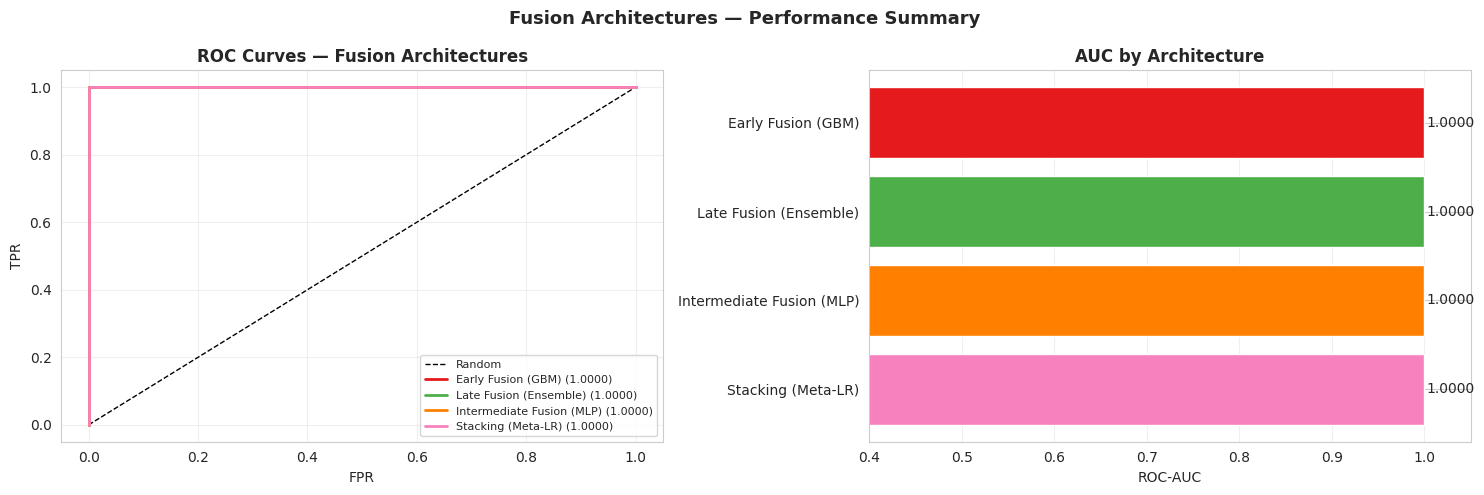


✓ Best architecture: Early Fusion (GBM) (AUC=1.0000)
Next: 03_ablation_studies.ipynb


In [7]:
# Build comparison table
comp_rows = []
for name, r in fusion_results.items():
    comp_rows.append({
        'Architecture': name,
        'Accuracy': round(r['accuracy'], 4),
        'F1': round(r['f1'], 4),
        'Precision': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'ROC-AUC': round(r['roc_auc'], 4),
        'Brier': round(r['brier'], 4),
    })

comp_df = pd.DataFrame(comp_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('FUSION ARCHITECTURE COMPARISON')
print('=' * 80)
print(comp_df.to_string(index=False))
comp_df.to_csv(FUSION_DIR / '02_fusion_comparison.csv', index=False)

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
palette = plt.cm.Set1(np.linspace(0, 0.8, len(fusion_results)))
for (name, r), color in zip(fusion_results.items(), palette):
    fpr, tpr, _ = roc_curve(y_val, r['proba'])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} ({r["roc_auc"]:.4f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Fusion Architectures', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# AUC bar chart
ax2 = axes[1]
archs = comp_df['Architecture'].tolist()
aucs  = comp_df['ROC-AUC'].tolist()
bars  = ax2.barh(archs, aucs, color=palette[:len(archs)], edgecolor='white')
for bar, val in zip(bars, aucs):
    ax2.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
ax2.set_xlabel('ROC-AUC'); ax2.set_title('AUC by Architecture', fontweight='bold')
ax2.set_xlim(0.4, 1.05); ax2.invert_yaxis()
ax2.grid(True, axis='x', alpha=0.3)

plt.suptitle('Fusion Architectures — Performance Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fusion_architectures_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_arch = comp_df.iloc[0]['Architecture']
print(f'\n✓ Best architecture: {best_arch} (AUC={comp_df.iloc[0]["ROC-AUC"]:.4f})')
print('Next: 03_ablation_studies.ipynb')